# Governed stack — notebook tour

This notebook is a **client** of the running stack, not a replacement for it. Start the stack first:

```
python stack.py up
```

Everything below goes through the governance gateway: token to role, OPA policy, per-role budget,
governed cache, audit. The last section reads the gov-lake DuckDB file directly to chart the
stack's own governance history.

In [1]:
from pathlib import Path
import json, requests

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BASE = "http://localhost:8765"

# Tokens come from the local stack.env (never hardcoded into the notebook).
env_file = ROOT / "stack.env"
if not env_file.exists():
    env_file = ROOT / "stack.env.example"
tokens = {}
for line in env_file.read_text(encoding="utf-8").splitlines():
    if line.startswith("GATEWAY_TOKENS="):
        for pair in line.split("=", 1)[1].split(","):
            tok, role = pair.strip().split(":", 1)
            tokens[role] = tok

def call(server, tool, body=None, role="manager"):
    r = requests.post(f"{BASE}/{server}/{tool}", json=body or {},
                      headers={"Authorization": f"Bearer {tokens[role]}"}, timeout=30)
    try:
        return r.status_code, r.json()
    except ValueError:
        return r.status_code, r.text

print("roles available:", sorted(tokens))

roles available: ['administrator', 'analyst', 'finance', 'manager', 'viewer']


## Governance in action

The same tool, three roles. The gateway asks OPA before anything reaches a tool, so the
difference below is policy, not code paths.

In [2]:
status, body = call("sql-steward", "list_metrics")
metrics = body.get("metrics", []) if isinstance(body, dict) else []
metric = metrics[0]["name"] if metrics else "mrr_total"
print("using metric:", metric)
print()

for role in ("viewer", "analyst", "manager"):
    if role not in tokens:
        continue
    status, body = call("sql-steward", "get_metric", {"metric": metric}, role=role)
    if isinstance(body, dict):
        outcome = body.get("detail") or body.get("error") or f"rowcount={body.get('rowcount')}"
    else:
        outcome = body
    print(f"{role:8} -> HTTP {status}  {outcome}")

using metric: yield_avg



viewer   -> HTTP 403  denied by policy: role not permitted for this tool


analyst  -> HTTP 200  rowcount=1


manager  -> HTTP 200  rowcount=1


In [3]:
# PII is refused inside the tool, whatever the caller's role. Find a PII-tagged
# field in the semantic layer and ask for it as the most powerful role available.
status, body = call("sql-steward", "list_entities")
entities = body.get("entities", []) if isinstance(body, dict) else []
target = None
for e in entities:
    status, desc = call("sql-steward", "describe_entity", {"entity": e["name"]})
    for f in desc.get("fields", []):
        if isinstance(f, dict) and f.get("pii"):
            target = (e["name"], f["name"])
            break
    if target:
        break

if target:
    role = "administrator" if "administrator" in tokens else "manager"
    status, resp = call("sql-steward", "get_records",
                        {"entity": target[0], "fields": [target[1]]}, role=role)
    print(f"{role} asks for {target[0]}.{target[1]}:")
    print(json.dumps(resp, indent=2)[:400])
else:
    print("no PII-tagged fields in this semantic layer")

administrator asks for runs.created_by:
{
  "refused": true,
  "kind": "pii_blocked",
  "detail": "Field 'runs.created_by' is tagged PERSON, which this policy refuses. Ask for a non-PII field or an aggregate instead.",
  "recovery": {
    "blocked_category": "PERSON",
    "field": "runs.created_by"
  }
}


In [4]:
# A compliance verdict is computed deterministically before any model sees it,
# and a viewer may read the verdict without any access to the raw tables.
status, verdict = call("compliance-check", "batch_compliance", {"batch_id": "B-1003"}, role="viewer")
print("HTTP", status)
print(json.dumps(verdict, indent=2))

HTTP 200
{
  "batch_id": "B-1003",
  "product_code": "PROD-C",
  "compliant": false,
  "findings": [
    {
      "check": "cold_chain",
      "passed": true,
      "detail": "all 2 readings within limit",
      "evidence": []
    },
    {
      "check": "allergen_crosscheck",
      "passed": false,
      "detail": "allergen(s) present on the line but not declared on the product",
      "evidence": [
        "Peanuts"
      ]
    }
  ],
  "policy_version": "cc-1.0"
}


## The lake: the stack analyzing its own governance history

`gov-lake` ingests the gateway's OTel span export and the hash-chained compliance ledger into a
local DuckDB file, and exposes pre-approved aggregations. Viewer is denied on purpose:
who-queried-what is sensitive metadata.

In [5]:
status, ratio = call("gov-lake", "cache_hit_ratio", {"days": 7}, role="analyst")
print("cache hit ratio:", json.dumps(ratio, indent=2) if status == 200 else f"HTTP {status} {ratio}")

status, body = call("gov-lake", "decision_summary", {"days": 7}, role="viewer")
print()
print("viewer asks for the decision summary -> HTTP", status,
      body.get("detail", "") if isinstance(body, dict) else "")

cache hit ratio: {
  "days": 7,
  "server": "all",
  "hits": 13,
  "misses": 56,
  "hit_ratio": 0.188,
  "lake": {
    "tool_calls": 92,
    "verdicts": 23,
    "verdict_chain_ok": true
  }
}



viewer asks for the decision summary -> HTTP 403 denied by policy: role not permitted for this tool


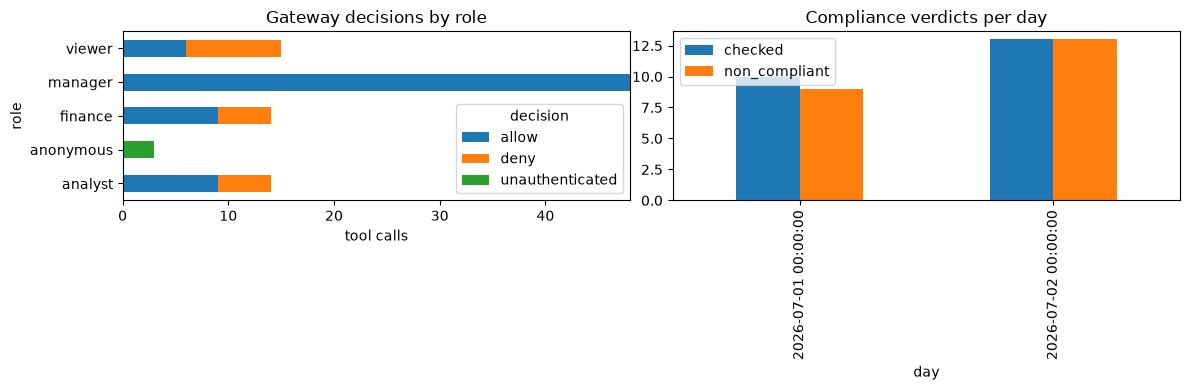

,role,decision,n
0,manager,allow,48
1,viewer,deny,9
2,finance,allow,9
3,analyst,allow,9
4,viewer,allow,6
5,finance,deny,5
6,analyst,deny,5
7,anonymous,unauthenticated,3


In [6]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

call("gov-lake", "refresh_lake", role="analyst")  # rebuild from the evidence files

lake = next((line.split("=", 1)[1].strip() for line in env_file.read_text(encoding="utf-8").splitlines()
             if line.startswith("GOV_LAKE_DB=")), str(ROOT / "data/lake/gov.duckdb"))
lake = lake.replace("{root}", ROOT.as_posix())
con = duckdb.connect(lake, read_only=True)

decisions = con.execute("""
    SELECT role, decision, COUNT(*) AS n FROM tool_calls GROUP BY role, decision ORDER BY n DESC
""").df()
trend = con.execute("""
    SELECT CAST(ts AS DATE) AS day, COUNT(*) AS checked,
           SUM(CASE WHEN compliant THEN 0 ELSE 1 END) AS non_compliant
    FROM verdicts GROUP BY day ORDER BY day
""").df()
con.close()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pivot = decisions.pivot_table(index="role", columns="decision", values="n", fill_value=0)
pivot.plot.barh(ax=axes[0], stacked=True)
axes[0].set_title("Gateway decisions by role")
axes[0].set_xlabel("tool calls")
trend.plot.bar(x="day", y=["checked", "non_compliant"], ax=axes[1])
axes[1].set_title("Compliance verdicts per day")
plt.tight_layout()
plt.show()

decisions.head(10)

## Things to try

- Change a role's allow-list in `policy/roles.json` and watch the same cells flip between 200 and 403 (OPA picks the file up on restart).
- Call the same `get_metric` twice and check the second response header `x-gov-cache: hit`.
- `call("gov-lake", "export_parquet", role="analyst")` and open the Parquet files in anything.
- Point `SQL_STEWARD_DB_URL` at a different database and re-run — the notebook discovers entities and metrics from the semantic layer, so nothing here is hardcoded to a dataset.